In [1]:
from datetime import time
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from dataclasses import dataclass
from pathlib import Path
import joblib

from config import (COMPONENTS_2D, MARKET_OPEN_SECONDS, PLOT, t_start, SAVE_DIR)
from diagnostics import diagnostics, plot_hjb_policy_heatmap
from event_cleaning import prepare_hawkes_events
from OrderBook import OrderBook
from HawkesCalibrator import LOBHawkes, HawkesCalibrator
from control_frame import ControlBacktester, simulate_mid_paths
from microstructure_calibration import calibrate_fill_probability, calibrate_price_impact
from plot_hawkes import HawkesPlotter
from utils import (t_rel, apply_time_of_day_axis, _sec_to_clock_str, _choose_tick_step)
from hjb_theta_solver  import (HJBThetaIMEXSolver, HJBSolverParams,
                             HJBQuotePolicyFromSolution, hjb_signature, 
                             cache_load_or_compute, estimate_sigma_arithmetic,
                             estimate_tick_size_from_series, estimate_quote_tick_from_bid_ask,
                             intensity_on_real_episode_2d, slice_event_counts,
                             slice_mid_episode, HawkesBacktestModel, HJBPolicyAdapter)

In [2]:
# msg_file = "LOBSTER_sample\GOOG_2012-06-21_34200000_57600000_message_10.csv"
# lob_file = "LOBSTER_sample\GOOG_2012-06-21_34200000_57600000_orderbook_10.csv"

In [3]:
# msg_file = "LOBSTER_sample\AMZN_2012-06-21_34200000_57600000_message_10.csv"
# lob_file = "LOBSTER_sample\AMZN_2012-06-21_34200000_57600000_orderbook_10.csv"

In [4]:
msg_file = "LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_message_10.csv"
lob_file = "LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\andre\AppData\Local\Temp\ipykernel_30372\50585678.py:1: SyntaxWarning: invalid escape sequence '\A'
  msg_file = "LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_message_10.csv"
C:\Users\andre\AppData\Local\Temp\ipykernel_30372\50585678.py:2: SyntaxWarning: invalid escape sequence '\A'
  lob_file = "LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"


In [5]:
symbol = Path(lob_file).name.split("_")[0]
print("ticker:", symbol)


ticker: AAPL


In [ ]:
print(f"Loading LOBSTER data: {msg_file} and {lob_file}")
ob = OrderBook(message_file=msg_file, orderbook_file=lob_file, ticker=symbol)
data = ob.LimitOrderBook
events, T_day = ob.to_hawkes_events_10d_robust(debug=True)

print(f"\n\nDeep Imbalance (rho_5L) calculated. Mean: {data['rho_5L'].mean():.4f}")

plotter = HawkesPlotter()

if PLOT:
    plotter.plot_price_action(data)

    plotter.plot_price_zoom(data, time(13, 0, 0), time(13, 10, 0))

    plotter.plot_candles(data, resample_rule='5T')

Loading LOBSTER data: LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_message_10.csv and LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_orderbook_10.csv
Loading LOBSTER data from:
 MSG: LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_message_10.csv
 LOB: LOBSTER_sample\AAPL_2012-06-21_34200000_57600000_orderbook_10.csv...


In [ ]:
df = ob.LimitOrderBook
df = df[df["time"] >= MARKET_OPEN_SECONDS].copy().reset_index(drop=True)
df["time"] -= MARKET_OPEN_SECONDS

ob.LimitOrderBook = df                                
data = ob.LimitOrderBook                              

events, T = ob.to_hawkes_events_10d_robust(debug=False)
events, marks, meta = prepare_hawkes_events(
    events_raw=events,
    components=COMPONENTS_2D,
    collapse_tol=0.0,
    global_tie_break=True,
    eps="auto"
)

print("[EVENT CLEAN] raw counts:", meta["n_raw"])
print("[EVENT CLEAN] collapsed counts:", meta["n_collapsed"])
print("[EVENT CLEAN] eps used:", meta["eps_used"])
print("[EVENT CLEAN] dt0_after:", meta["dt0_after"])

print(f"\n\nBuilt 10D events, T_day = {T:.1f} seconds")
lob2 = LOBHawkes(events, T)


[EVENT CLEAN] raw counts: {'E_b': 18261, 'E_a': 16729}
[EVENT CLEAN] collapsed counts: {'E_b': 13082, 'E_a': 11779}
[EVENT CLEAN] eps used: 7.700000423938036e-10
[EVENT CLEAN] dt0_after: {'E_b': {'n': 13082, 'share_dt0': 0.0}, 'E_a': {'n': 11779, 'share_dt0': 0.0}}


Built 10D events, T_day = 23399.9 seconds


In [ ]:
FILENAME = f"hawkes_2d_fit_results_{symbol}.pkl"
FILEPATH = os.path.join(SAVE_DIR, FILENAME)

# Ensure directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

windows = [
    (t_rel(10, 0), t_rel(12, 0)),
    (t_rel(12, 0), t_rel(14, 0)),
    (t_rel(14, 0), t_rel(16, 0))
]

print("\nFitting 2D Hawkes on windows:")
for k, (t0, t1) in enumerate(windows):
    print(f"  window {k}: [{t0:.0f}, {t1:.0f})  (len={(t1-t0):.0f}s)")

# ------------------------------------------------------------------
# 4) Calibra Hawkes 2D per finestre (WITH CACHING)
#    -> ottieni dict: {win_idx: WindowResult2D}
# ------------------------------------------------------------------
if os.path.exists(FILEPATH):
    print(f"\n[CACHE] Found saved fit at '{FILEPATH}'. Loading...")
    with open(FILEPATH, "rb") as f:
        win_results = pickle.load(f)
    print("[CACHE] Loaded successfully.")
else:
    print(f"\n[CACHE] File '{FILEPATH}' not found. Running calibration...")
    
    win_results = lob2.fit_windows(
        windows,
        deseasonalize=False,
        rho_cap_fit=0.999,     # fit is “free” but prevented from going supercritical
    )

    
    print(f"[CACHE] Saving results to '{FILEPATH}'...")
    with open(FILEPATH, "wb") as f:
        pickle.dump(win_results, f)
    print("[CACHE] Saved.")

# --- Verification of loaded/fitted results ---
print("\n=== Window fits summary ===")
for k in sorted(win_results.keys()):
    wr = win_results[k]
    print(f"Window {k}: [{wr.t0:.0f}, {wr.t1:.0f}), rho={wr.fit.rho:.3f}")
    for name, mZ in zip(COMPONENTS_2D, wr.meanZ):
        print(f"   {name}: mean(Z)={mZ:.3f}")
    print()




Fitting 2D Hawkes on windows:
  window 0: [1800, 9000)  (len=7200s)
  window 1: [9000, 16200)  (len=7200s)
  window 2: [16200, 23400)  (len=7200s)

[CACHE] Found saved fit at 'cache\hawkes_2d_fit_results_AAPL.pkl'. Loading...
[CACHE] Loaded successfully.

=== Window fits summary ===
Window 0: [1800, 9000), rho=0.501
   E_b: mean(Z)=1.083
   E_a: mean(Z)=0.951

Window 1: [9000, 16200), rho=0.496
   E_b: mean(Z)=1.000
   E_a: mean(Z)=0.998

Window 2: [16200, 23400), rho=0.473
   E_b: mean(Z)=0.998
   E_a: mean(Z)=1.002



In [ ]:
def pick_fit_for_time(win_results, t_start):
    for k, wr in win_results.items():
        if wr.t0 <= t_start < wr.t1:
            return wr.fit
    raise ValueError(f"t_start={t_start} not covered by fitted windows.")

fit_res = pick_fit_for_time(win_results, t_start)

print(f"Mu: {fit_res.mu}")
print(f"Alpha:\n{fit_res.A}")
print(f"Beta: {fit_res.beta}")

Mu: [0.19296865 0.16006834]
Alpha:
[[194.17253481  10.82949172]
 [  8.8344362  193.45371573]]
Beta: [432.01211182 399.73886979]


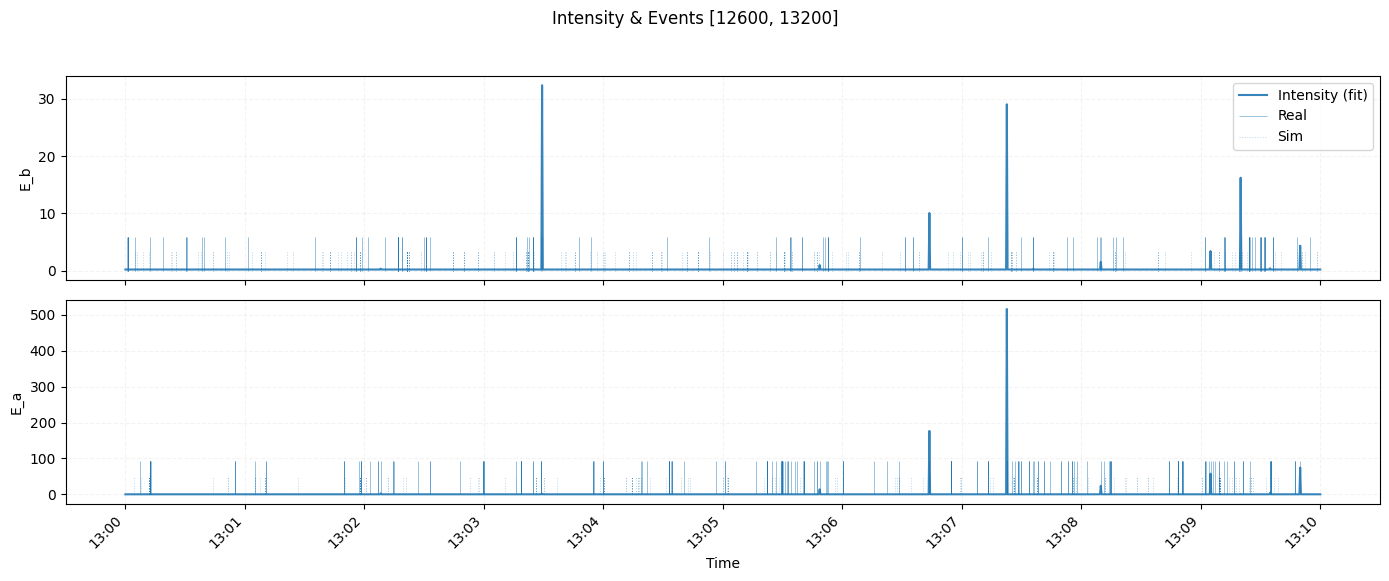

In [ ]:
t0_abs = t_start
t1_abs = t_start + 10 * 60

fig, axes = plotter.plot_frame_events_and_intensity_2D(
    lob2,
    win_results,
    t0_abs=t0_abs,
    t1_abs=t1_abs,
    seed=42,
    n_grid=20_000,
    max_events=1200,
    show_clock=True,        
)
if PLOT:
    plt.show()


In [ ]:
print("--- Calibrating Market (tick + sigma) and Microstructure ---\n")


quote_tick = estimate_quote_tick_from_bid_ask(
    data["bid_price"].values, data["ask_price"].values
)

mid_tick = estimate_tick_size_from_series(data["mid_price"].values)


sigma_hat = estimate_sigma_arithmetic(
    mid=data["mid_price"].values,
    t=data["time"].values,
    dt_vol=1.0
)
print(f"Estimated quote tick: {quote_tick:.4f}")
print(f"Estimated mid tick: {mid_tick:.4f}")
print(f"[CALIB] sigma_hat ≈ {sigma_hat}  (price/sqrt(s))")

def micro_cache_path(symbol: str, quote_tick: float, mid_tick: float, max_levels: int, delta_max_fit: float | None, horizon_events: int):
    dmax_tag = "None" if delta_max_fit is None else str(delta_max_fit).replace(".", "p")
    return Path(SAVE_DIR) / f"micro_params_{symbol}_qt{quote_tick:.6g}_mt{mid_tick:.6g}_L{max_levels}_dmax{dmax_tag}_h{horizon_events}.pkl"

H = 5
micro_path = micro_cache_path(symbol, quote_tick, mid_tick, max_levels=3, delta_max_fit=0.05, horizon_events=H)


def _compute_micro():

    A_fill, k_fill, delta0_fill = calibrate_fill_probability(
        lob_data=df,
        tick_size=quote_tick,
        max_levels=10,
        delta_max_fit=12 * quote_tick,
    )

    p_bar, k_imp, theta_imp = calibrate_price_impact(
        None,
        data,
        tick_size=mid_tick,
        horizon_events=5,
    )


    return dict(A_fill=A_fill, k_fill=k_fill, delta0_fill=delta0_fill,
                p_bar=p_bar, k_imp=k_imp, theta_imp=theta_imp)




micro_params = cache_load_or_compute(micro_path, _compute_micro)
A_fill = micro_params["A_fill"]
k_fill = micro_params["k_fill"]
delta0_fill = micro_params["delta0_fill"]
p_bar  = micro_params["p_bar"]
k_imp  = micro_params["k_imp"]
theta_imp = micro_params["theta_imp"]
delta0_fill = micro_params["delta0_fill"]


print(f"[CALIB] fill: A={A_fill:.4g}, k={k_fill:.4g}, delta0={delta0_fill:.6g}")
print(f"[CALIB] impact: p_bar={p_bar:.4g}, k_imp={k_imp:.4g}, theta={theta_imp:.4g}")

--- Calibrating Market (tick + sigma) and Microstructure ---

Estimated quote tick: 0.0100
Estimated mid tick: 0.0050
[CALIB] sigma_hat ≈ 0.03478314570199445  (price/sqrt(s))
[CALIB] fill: A=0.3168, k=22.84, delta0=0.045
[CALIB] impact: p_bar=0.9, k_imp=0.07588, theta=-0.7525


In [ ]:
# --- HJB parameters ---
dt_bt = 0.1
T_hjb = 6000.0
n_grid_points = int(T_hjb / dt_bt) + 1


idx_minus = COMPONENTS_2D.index("E_b")  # lambda^-
idx_plus  = COMPONENTS_2D.index("E_a")  # lambda^+

mu_plus  = fit_res.mu[idx_plus]
mu_minus = fit_res.mu[idx_minus]

beta_plus  = fit_res.beta[idx_plus]
beta_minus = fit_res.beta[idx_minus]

# A in (+,-) ordering (rows=affected intensity, cols=event type)
A_fit = fit_res.A
A_pm = np.array([
    [A_fit[idx_plus,  idx_plus],  A_fit[idx_plus,  idx_minus]],
    [A_fit[idx_minus, idx_plus],  A_fit[idx_minus, idx_minus]],
])

In [ ]:
dt_hjb = 0.10
store_dt = 1.0
store_every_steps = int(round(store_dt / dt_hjb))

params = HJBSolverParams(
    T=T_hjb,
    n_time=int(T_hjb / dt_hjb),

    Q=5,
    q0=1,

    gamma=0.8,
    eta=0.02,
    eta_T=0.02,
    eta_run=1e-4,

    sigma=sigma_hat,
    kappa_jump=mid_tick,
    quote_tick=quote_tick,

    delta_min=mid_tick,
    delta_step=3 * mid_tick,
    delta_max=0.06,

    delta0_fill_a=delta0_fill,
    delta0_fill_b=delta0_fill,
    A_fill_a=A_fill,
    A_fill_b=A_fill,
    k_fill_a=k_fill,
    k_fill_b=k_fill,

    p_bar=p_bar,
    k_imp=k_imp,
    theta_imp=theta_imp,

    M_plus=15,
    M_minus=15,

    store_every=store_every_steps,
)

In [ ]:
# dt_hjb = 0.01
# store_dt = 0.1   # 100ms invece di 1s
# store_every_steps = int(round(store_dt / dt_hjb))


# params = HJBSolverParams(
#     T=T_hjb,
#     n_time=int(T_hjb / dt_hjb),
#     Q=20,
#     q0=1,
#     gamma=0.8,
#     eta=0.02,
#     eta_T=0.02,
#     eta_run=1e-4,    
#     sigma=sigma_hat,
#     kappa_jump=mid_tick,
#     quote_tick=quote_tick,
#     delta_min=mid_tick,
#     delta_step=mid_tick,
#     delta_max=0.20,
#     delta0_fill_a=delta0_fill,
#     delta0_fill_b=delta0_fill,
#     A_fill_a=A_fill,
#     A_fill_b=A_fill,
#     k_fill_a=k_fill,
#     k_fill_b=k_fill,
#     p_bar=p_bar,
#     k_imp=k_imp,
#     theta_imp=theta_imp,
#     M_plus=45,
#     M_minus=45,
#     store_every=store_every_steps,
# )

solver = HJBThetaIMEXSolver(mu_plus, mu_minus, A_pm, beta_plus, beta_minus, params)

In [ ]:
def load_or_solve_hjb(
    symbol: str,
    solver,
    params: HJBSolverParams,
    cache_dir: str | Path = "cache",
    compress: int = 3,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    safe_symbol = "".join(c for c in symbol if c.isalnum() or c in ("_", "-", "."))
    sig = hjb_signature(params)
    filepath = cache_dir / f"hjb_sol_{safe_symbol}_{sig}.joblib"

    if filepath.exists():
        print(f"\n[CACHE] Found saved HJB solution for '{symbol}' at '{filepath}'. Loading...")
        sol = joblib.load(filepath)
        print("[CACHE] Loaded successfully.")
    else:
        print(f"\n[CACHE] File '{filepath}' not found. Solving HJB for '{symbol}'...")
        sol = solver.solve()
        print(f"[CACHE] Saving HJB solution to '{filepath}'...")
        joblib.dump(sol, filepath, compress=compress)
        print("[CACHE] Saved.")

    return sol


sol = load_or_solve_hjb(symbol=symbol, solver=solver, params=params)
optimal_policy = HJBQuotePolicyFromSolution(sol)


[CACHE] Found saved HJB solution for 'AAPL' at 'cache\hjb_sol_AAPL_86c04ce8b6.joblib'. Loading...
[CACHE] Loaded successfully.


In [ ]:
sim_engine = HawkesCalibrator(lob2.events, T_hjb)
t_data = data["time"].values
mid_data = data["mid_price"].values

streams, (t_sim, c_sim), (t_grid, lam_grid) = sim_engine.simulate_and_intensity(
    fit_res.mu,
    fit_res.A,
    fit_res.beta,
    T=T_hjb,
    n_grid=n_grid_points,
    seed=42
)

mid_real_grid = np.interp(t_start + t_grid, t_data, mid_data)
mid0 = float(mid_real_grid[0])
mid_price = np.full_like(t_grid, mid0, dtype=float)


lam_plus_path  = lam_grid[idx_plus, :]
lam_minus_path = lam_grid[idx_minus, :]

In [ ]:
backtester = ControlBacktester(
    policy=optimal_policy,
    arrival= HawkesBacktestModel(A_fill=A_fill, k_fill=k_fill, delta0_fill=delta0_fill),
    Q_max=params.Q,
    tick_size=mid_tick,
    sigma=params.sigma,
    p_bar=params.p_bar,
    k_imp=params.k_imp,
    theta=params.theta_imp,
)

In [ ]:
t_grid_real, lam_plus_real, lam_minus_real = intensity_on_real_episode_2d(
    events=events,
    fit_res=fit_res,
    t_start=t_start,
    T=T_hjb,
    n_grid_points=n_grid_points
)

N_plus_counts, N_minus_counts = slice_event_counts(events, t_start, T_hjb, t_grid_real)
mid_real_grid = slice_mid_episode(data, t_start, T_hjb, t_grid_real)

res = backtester.run(
    mid=np.full_like(t_grid_real, mid_real_grid[0], dtype=float),
    mid_replay=mid_real_grid,
    t_secs=t_grid_real,
    lam_plus_path=lam_plus_real,
    lam_minus_path=lam_minus_real,
    N_plus_counts=N_plus_counts,
    N_minus_counts=N_minus_counts,
    seed=42,
)

In [ ]:
if PLOT:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    ax = axes[0]

    ax.plot(res['time'], res["bid"], label="Bid", lw=0.8, alpha=0.35, zorder=1)
    ax.plot(res['time'], res["ask"], label="Ask", lw=0.8, alpha=0.35, zorder=1)

    ax.plot(res['time'], res["mid"], label="Mid", lw=2.5, ls="--", zorder=5)

    ax.fill_between(res['time'], res["bid"], res["ask"], alpha=0.08, zorder=0)

    ax.legend()


    
    axes[1].plot(res['time'], res['q'], color='blue')
    axes[1].axhline(params.Q, ls='--', color='gray')
    axes[1].axhline(-params.Q, ls='--', color='gray')
    axes[1].set_ylabel("Inventory q")
    axes[1].set_title("Inventory Evolution")
    
    axes[2].plot(res['time'], res['pnl'], color='green')
    axes[2].set_ylabel("PnL")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Cumulative Profit & Loss")
    
    plt.tight_layout()
    plt.show()

In [ ]:
diag = diagnostics(symbol, data, events)
diag.make_all_figures(
    fit_res=fit_res, 
    t_start=t_start,
    T=T_hjb,
    policy=backtester.policy,
    res=res, 
    A_fill=params.A_fill_a,
    k_fill=params.k_fill_a,
    p_bar=params.p_bar,
    k_imp=params.k_imp,
    theta_imp=params.theta_imp,
    quote_tick=quote_tick,
    mid_tick=mid_tick,
    hc_for_residuals=None 
)

In [ ]:
report = diag.backtest_report(
    res,
    params=params,
    sol=sol,
    policy=backtester.policy,
    A_fill=A_fill, k_fill=k_fill,
    N_plus_counts=N_plus_counts,
    N_minus_counts=N_minus_counts,
    lam_plus_real=lam_plus_real,
    lam_minus_real=lam_minus_real,
    i_probe=50,
    verbose=True,
)

=== Backtest diagnostics report ===
params: gamma=0.8  eta=0.02  eta_T=0.02  eta_run=0.0001
PnL: trade=48.1885  mtm=-32.9135  total=15.275  (end_rel=15.275)
Wealth identity: ptp=18.285  max|wealth-pnl|=0
Micro: mean_spread=0.11625  mean_delta_b=0.0579171  mean_delta_a=0.0583333  corr(q,skew)=-0.85218
FillModel: mean_prob ask=0.0871368  bid=0.0875806  |  exp_fills ask=192.933  bid=187.692  total=380.625
ExecQuality: avg_sell_cap=0.0230659  avg_buy_cap=0.0293702  fills(sell)=440  fills(buy)=441  events(sell)=336  events(buy)=350
Grid hits: lam_plus_hit=0.00384994  lam_minus_hit=0.00403327
Policy sanity:
  t=0  q=10: skew=-0.01  del_b=0.065  del_a=0.045
  t=0  q=-10: skew=0.01  del_b=0.045  del_a=0.065
  i=50  q=10: skew=-0.01  del_b=0.06  del_a=0.04
  i=50  q=-10: skew=0.01  del_b=0.04  del_a=0.06


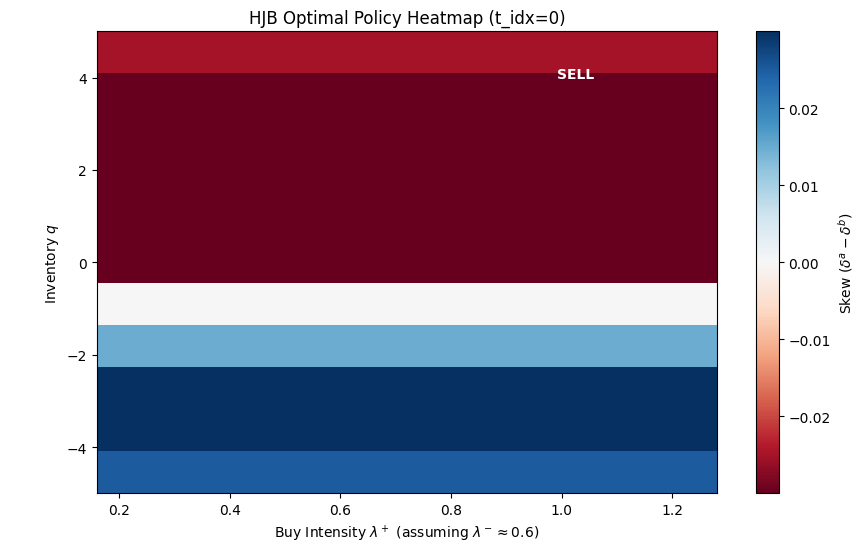

In [ ]:
plot_hjb_policy_heatmap(sol, t_idx=0)

[E_a] N/T = 0.372333 | Λ/T = 0.347842 | z = 3.217
[E_b] N/T = 0.370833 | Λ/T = 0.369731 | z = 0.140


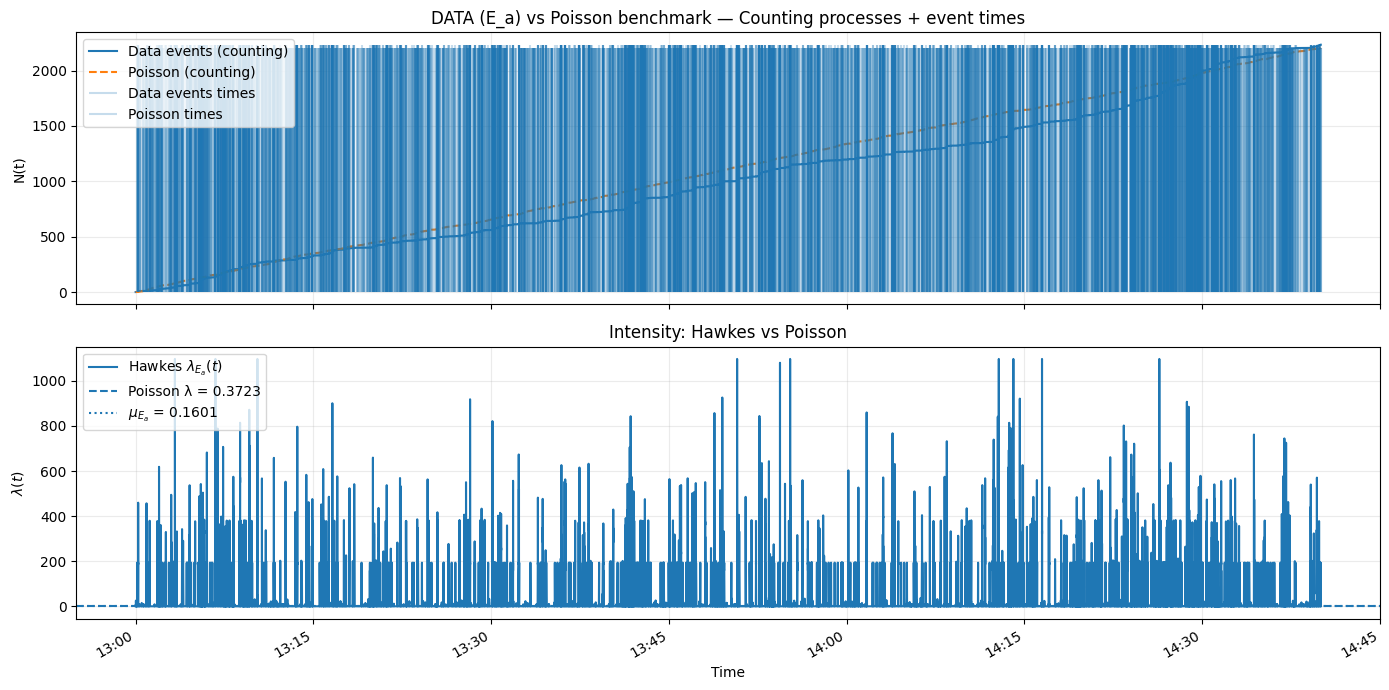

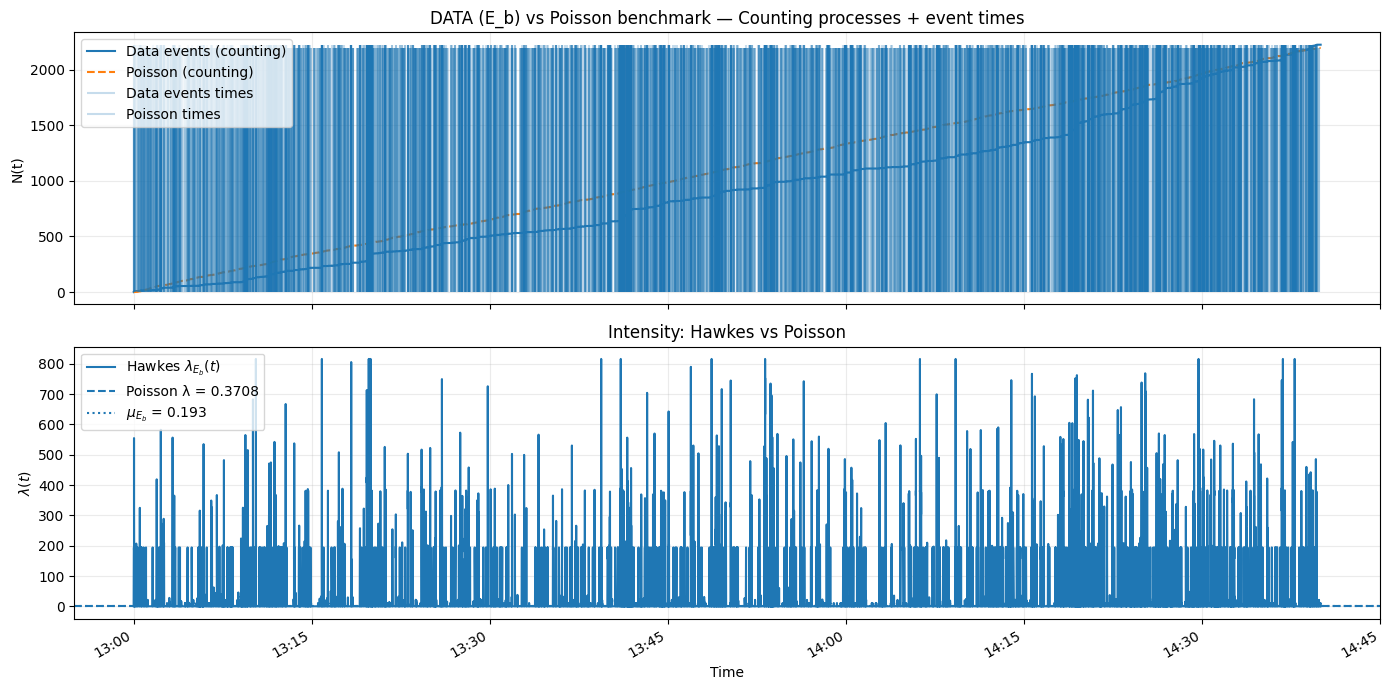

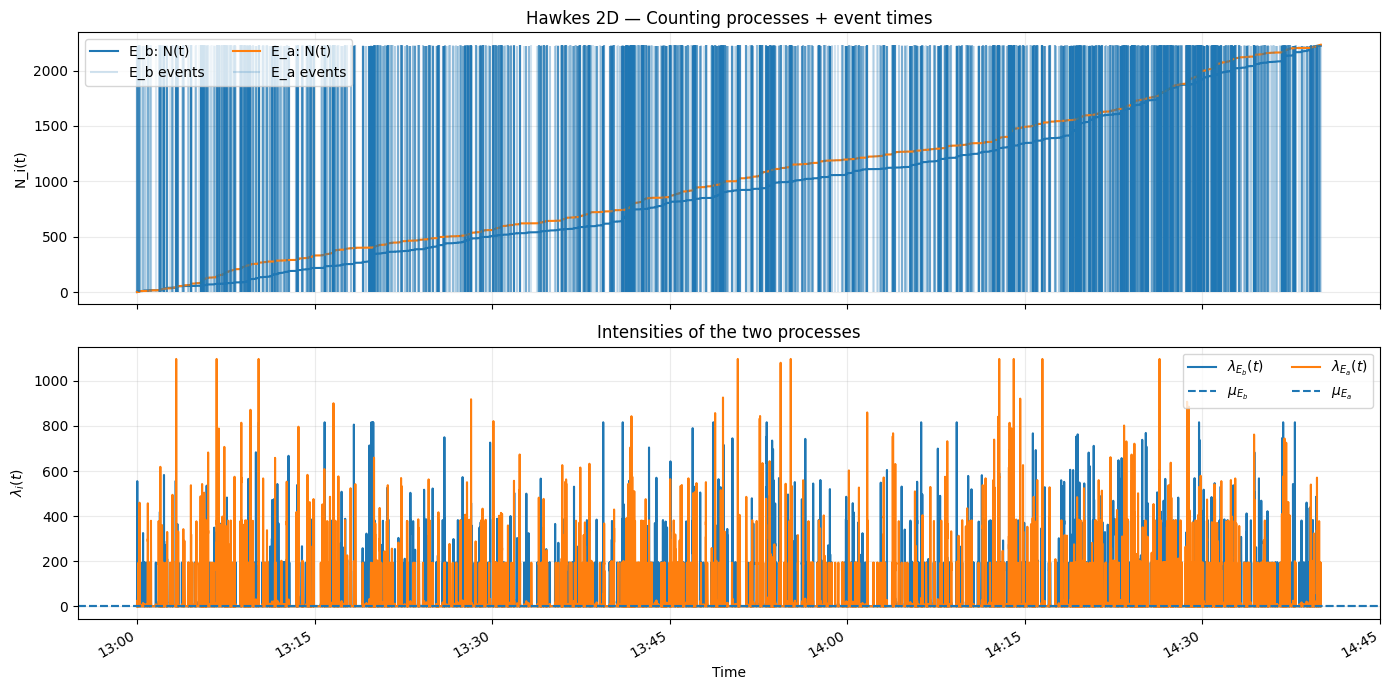

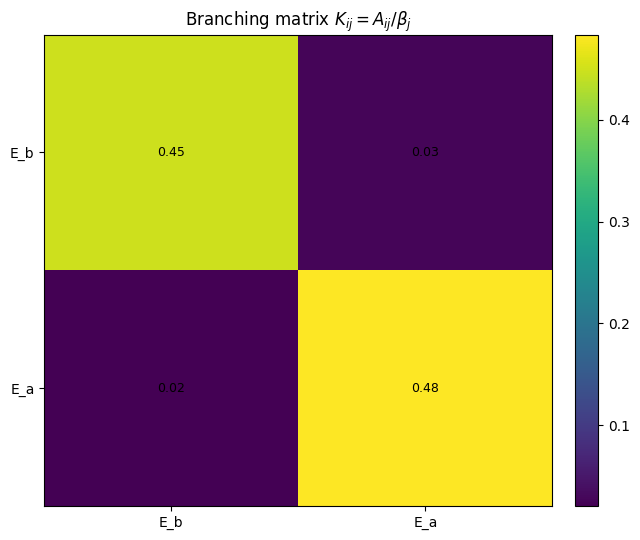

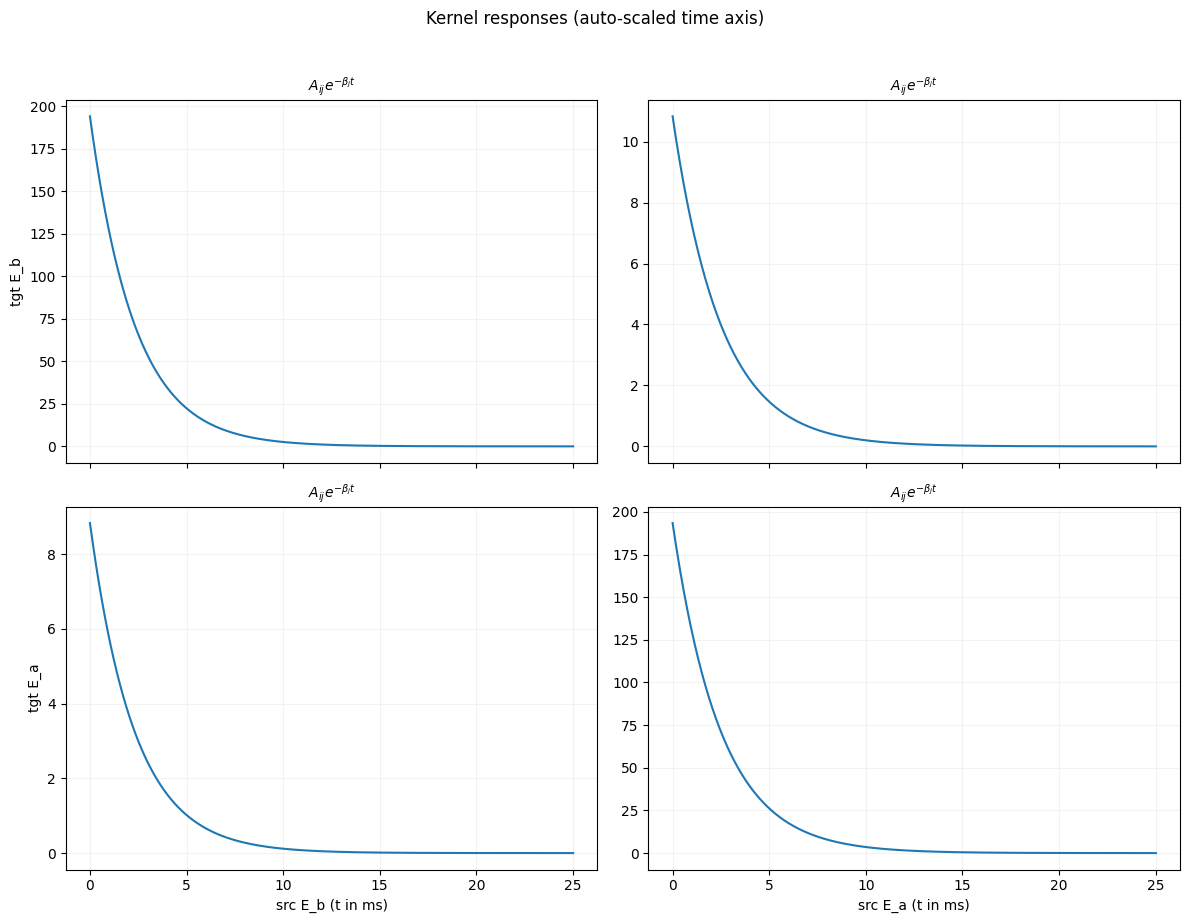

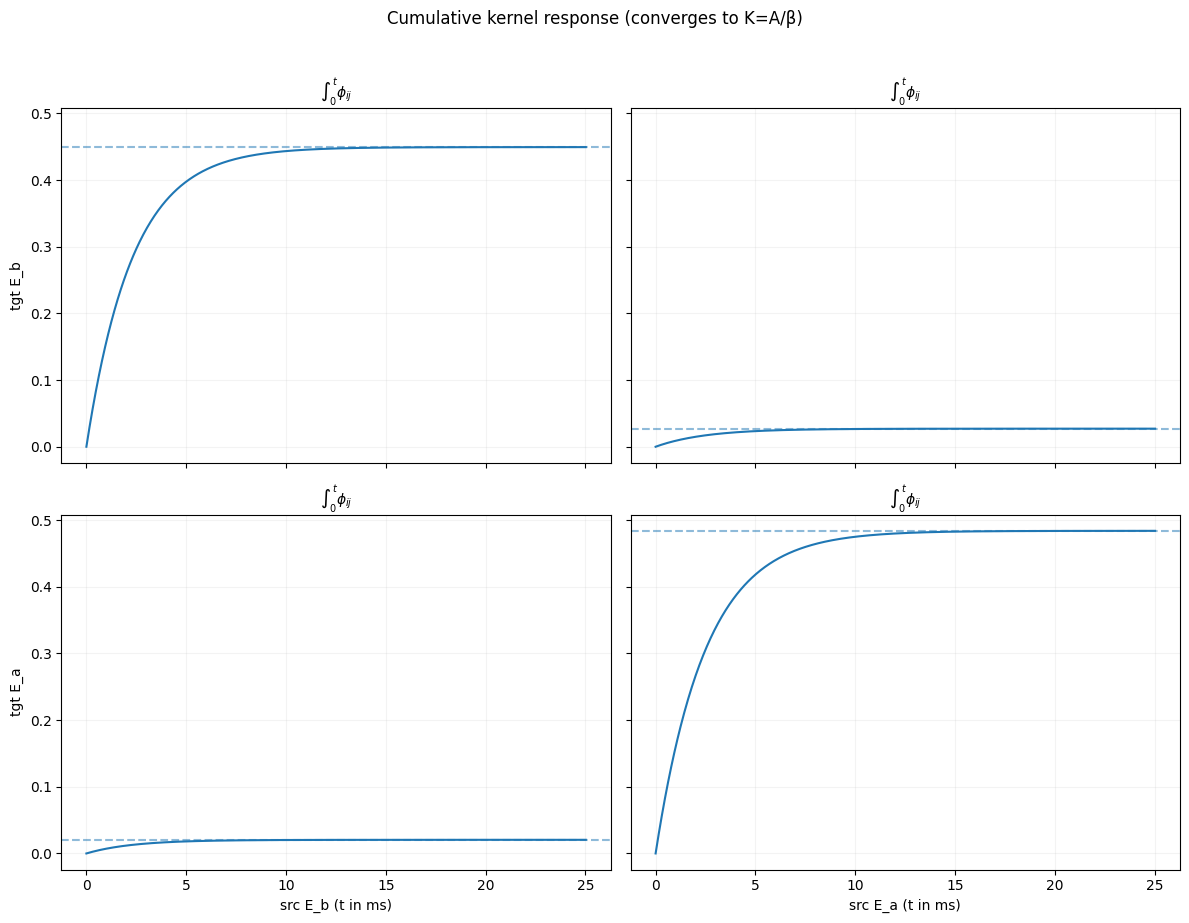

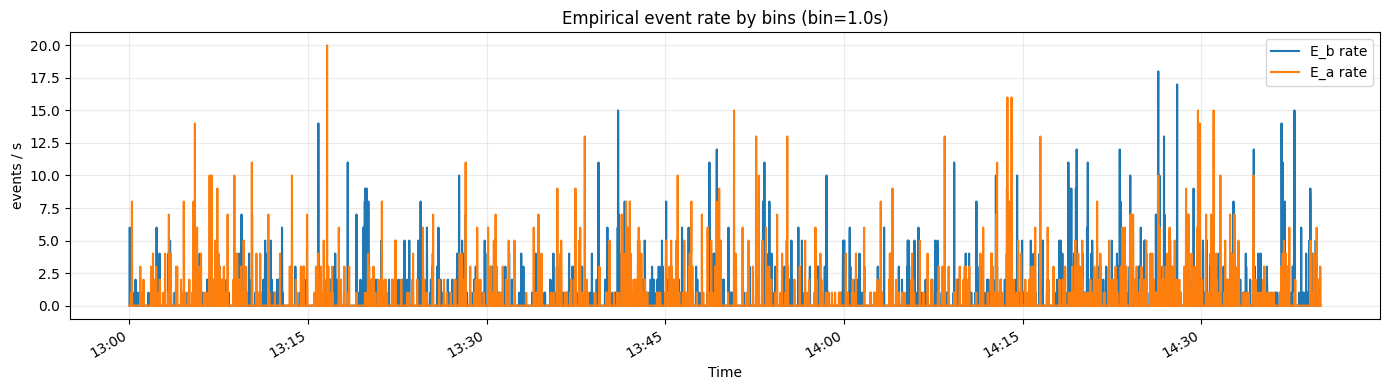

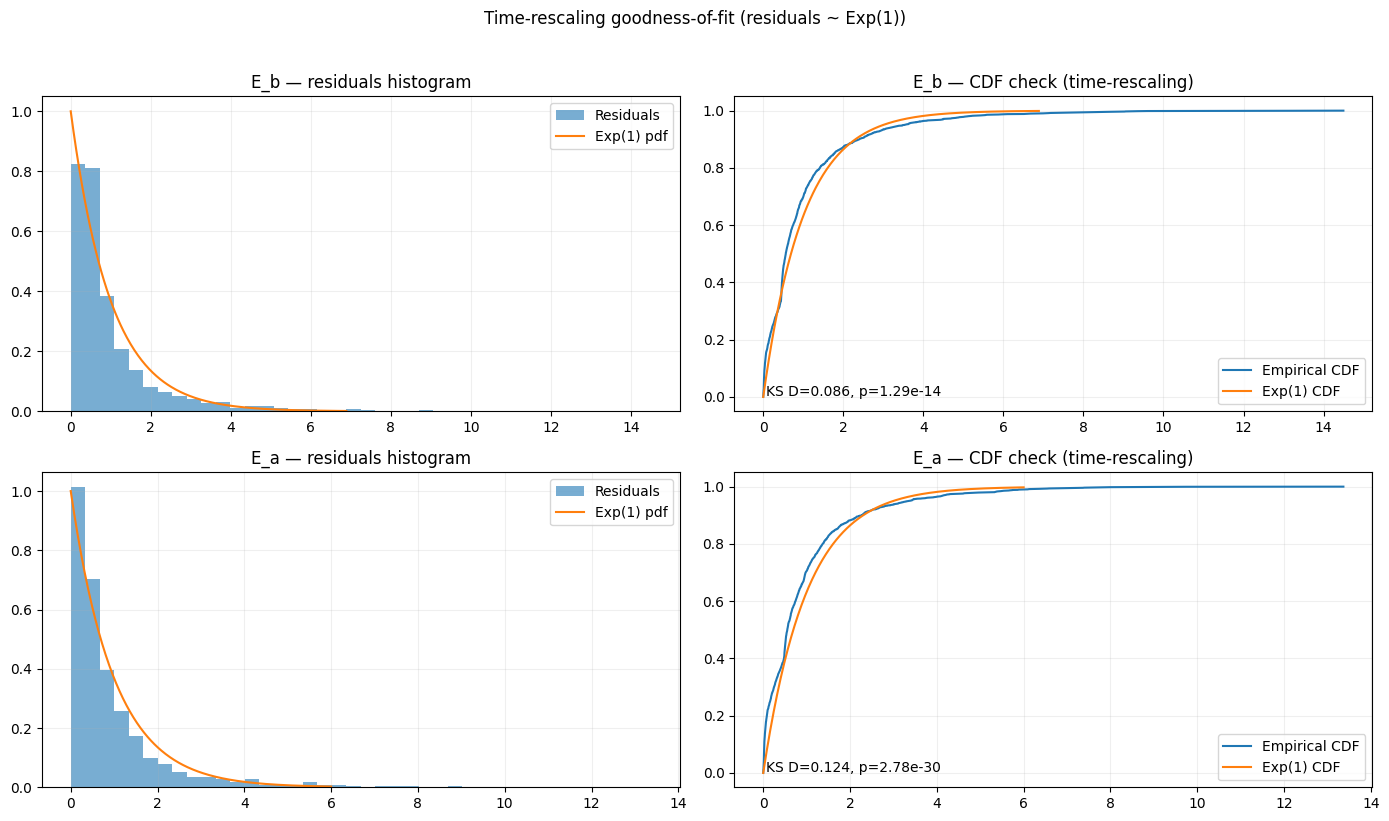

In [ ]:

from  PointProcessPlotSuite import PointProcessPlotSuite

pp = PointProcessPlotSuite(events=events, fit_res=fit_res)

# scegli un episodio
T_pp = T_hjb              # es: 180s

# include some pre-history so the Hawkes intensity at t_start is not artificially reset
warmup_pp = float(max(60.0, 10.0 * np.max(1.0 / fit_res.beta)))

# genera e salva tutte le figure
figs = pp.make_suite(
    t_start=t_start,
    T=T_pp,
    warmup=warmup_pp,
    out_dir="figures/" + str(symbol),
    seed=42
)

if PLOT:
    plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
C:\Users\andre\AppData\Local\Temp\ipykernel_47176\3181015286.py:55: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(res_hjb['q'], label=f"HJB ($\gamma=0.8$)", fill=True, color='blue', alpha=0.3)


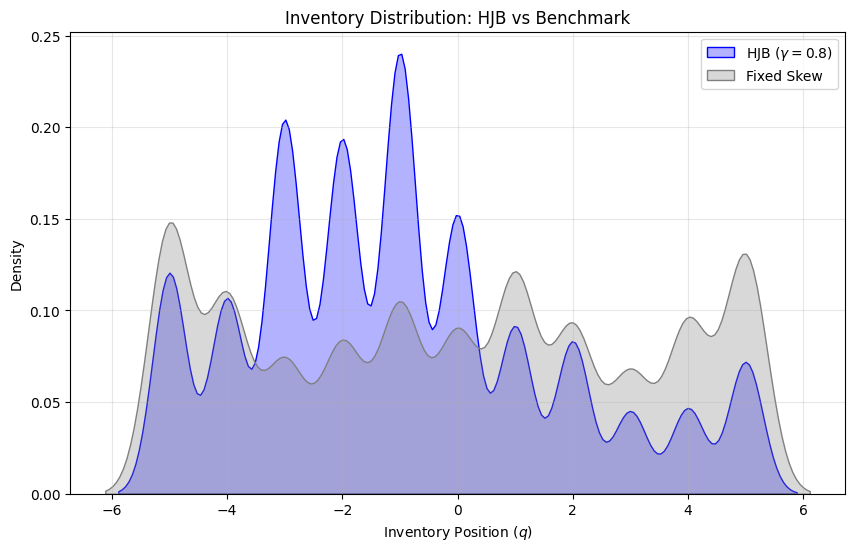

In [ ]:
from control_frame import FixedSkewFromMidPolicy

fixed_policy = FixedSkewFromMidPolicy(
    delta0=2 * quote_tick,     # base half-spread
    skew=1 * quote_tick,       # fixed skew
    quote_tick=quote_tick
)

fixed_backtester = ControlBacktester(
    policy=fixed_policy,
    arrival=HawkesBacktestModel(A_fill=A_fill, k_fill=k_fill, delta0_fill=delta0_fill),
    Q_max=params.Q,
    tick_size=mid_tick,
    sigma=params.sigma,
    p_bar=params.p_bar,
    k_imp=params.k_imp,
    theta=params.theta_imp,
)

res_fixed = fixed_backtester.run(
    mid=np.full_like(t_grid_real, mid_real_grid[0], dtype=float),
    mid_replay=mid_real_grid,
    t_secs=t_grid_real,
    lam_plus_path=lam_plus_real,
    lam_minus_path=lam_minus_real,
    N_plus_counts=N_plus_counts,
    N_minus_counts=N_minus_counts,
    seed=42,   # keep same seed for a fairer comparison
)

# --- Same plot format as HJB, now for fixed-skew ---
q_grid = np.arange(-30, 31, 2)
S0 = float(np.nanmedian(data["mid_price"].values))
mu = getattr(fit_res, "mu", None)
lam_minus0 = float(mu[0]) if (mu is not None and len(mu) >= 2) else 1.0
lam_plus0  = float(mu[1]) if (mu is not None and len(mu) >= 2) else 1.0

diag.fig_policy_slices(
    fixed_policy,
    t=0.0, S=S0,
    lam_plus=lam_plus0, lam_minus=lam_minus0,
    q_grid=q_grid,
    name="D1_policy_slices_fixed_skew",
)

diag.fig_backtest_path(res_fixed, name="E1_backtest_path_fixed_skew", t0_seconds=t_start, plot=PLOT)
diag.fig_pnl_decomposition(res_fixed, name="E2_pnl_decomposition_fixed_skew", t0_seconds=t_start, plot=PLOT)
diag.fig_compare_pnl_q(res, res_fixed, labels=("HJB", "FixedSkew"), name="E1b_compare_pnl_q", t0_seconds=t_start, plot=PLOT)


def plot_inventory_distribution(res_hjb, res_fixed):
    plt.figure(figsize=(10, 6))
    
    # HJB Inventory
    sns.kdeplot(res_hjb['q'], label=f"HJB ($\gamma=0.8$)", fill=True, color='blue', alpha=0.3)
    
    # Benchmark Inventory
    sns.kdeplot(res_fixed['q'], label="Fixed Skew", fill=True, color='gray', alpha=0.3)
    
    plt.title("Inventory Distribution: HJB vs Benchmark")
    plt.xlabel("Inventory Position ($q$)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run this after your backtest loop in main.py
plot_inventory_distribution(res, res_fixed)

In [ ]:
def localize_events(events_dict, t_start, T):
    out = {}
    for k, v in events_dict.items():
        v = np.asarray(v, float)
        m = (v >= t_start) & (v < t_start + T)
        out[k] = v[m] - t_start
    return out


In [ ]:
events_full_raw, T_day = ob.to_hawkes_events_10d_robust(debug=False)

events_full_clean, _, _ = prepare_hawkes_events(
    events_raw=events,
    components=COMPONENTS_2D,
    collapse_tol=0.0,
    global_tie_break=True,
    eps="auto"
)

T_EP = 600.0
events_full = localize_events(events_full_clean, t_start=t_start, T=T_EP)

# your 2D events too (if needed)
events_2d = localize_events(events, t_start=t_start, T=T_EP)  # if `events` is still absolute


(<Figure size 900x480 with 1 Axes>,
 <Axes: title={'center': 'Count distribution in fixed bins: real vs simulated'}, xlabel='count per 1s bin', ylabel='probability'>,
 {'xs': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
         17, 18]),
  'pmf_real': array([0.675     , 0.14      , 0.05166667, 0.05333333, 0.02      ,
         0.015     , 0.00666667, 0.01166667, 0.00333333, 0.00666667,
         0.00666667, 0.00166667, 0.00333333, 0.        , 0.        ,
         0.        , 0.        , 0.00333333, 0.00166667]),
  'pmf_sim': array([0.83666667, 0.09333333, 0.03666667, 0.01166667, 0.00333333,
         0.005     , 0.005     , 0.00166667, 0.00166667, 0.00166667,
         0.        , 0.        , 0.00166667, 0.00166667, 0.        ,
         0.        , 0.        , 0.        , 0.        ])})

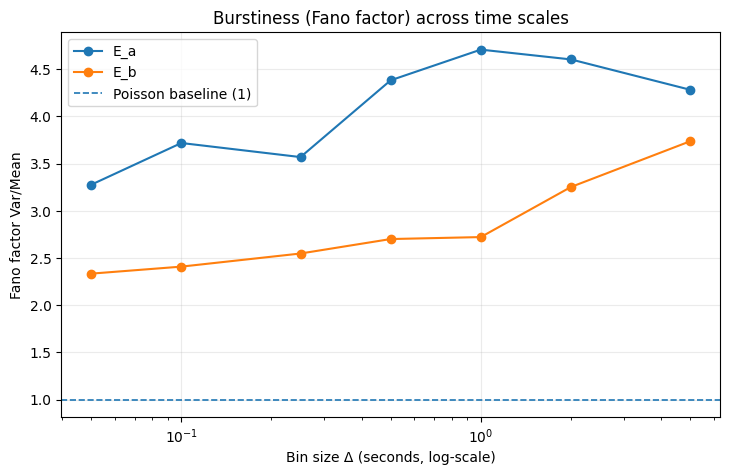

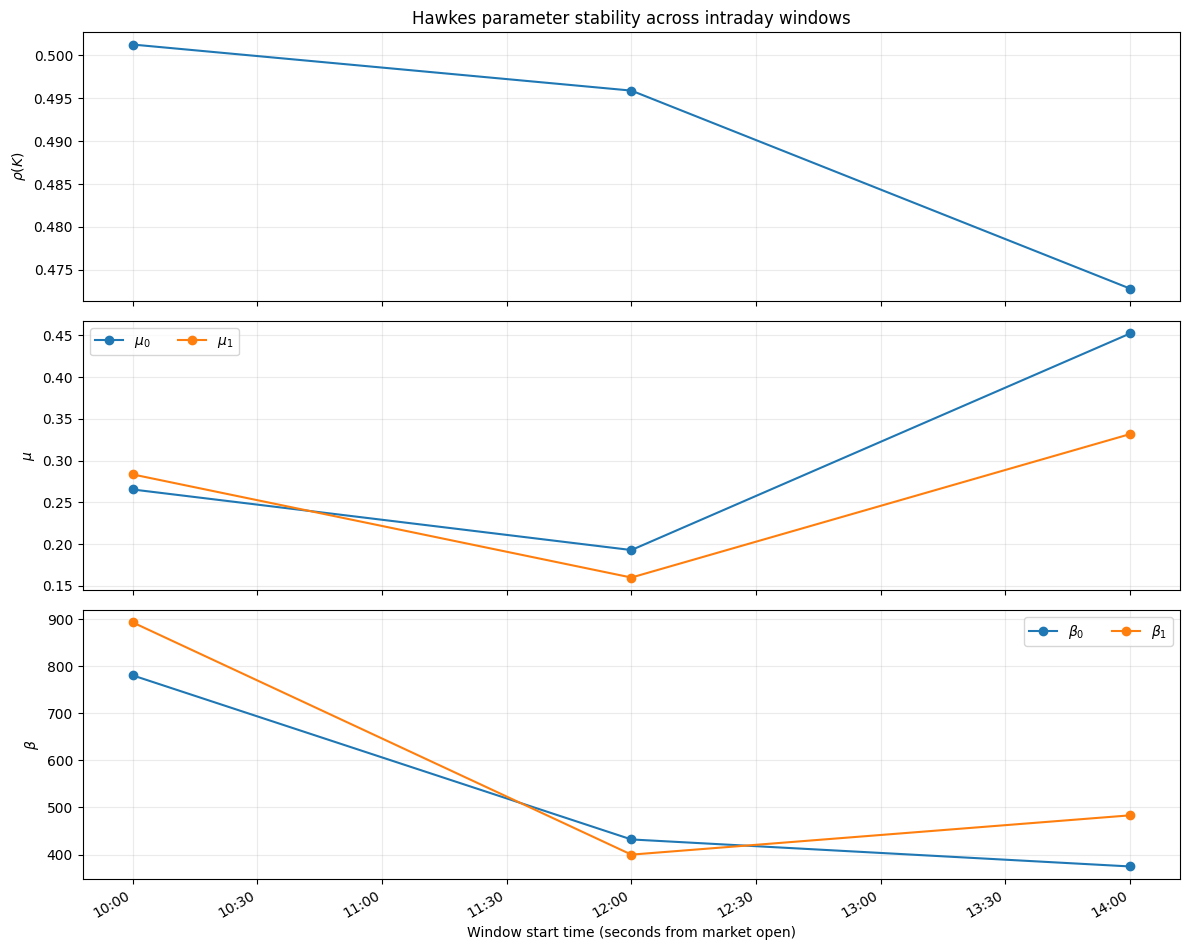

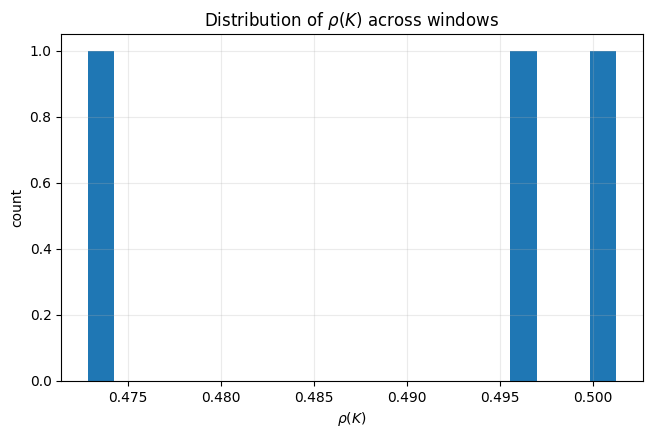

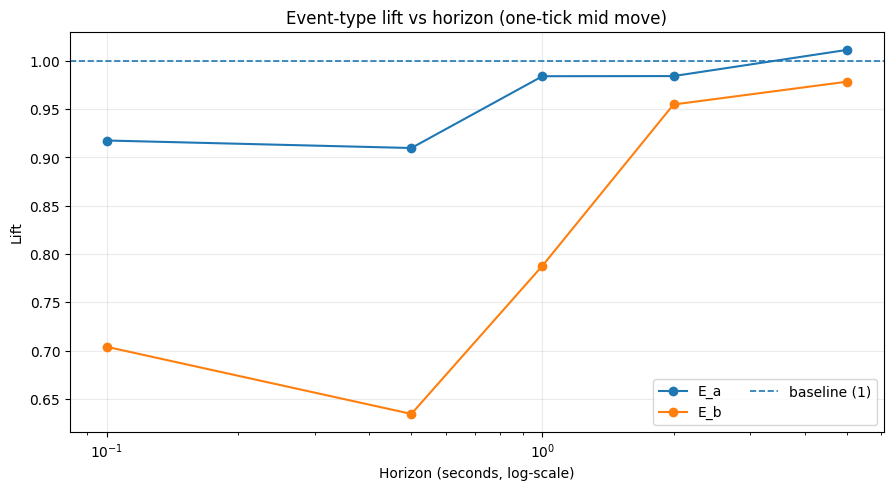

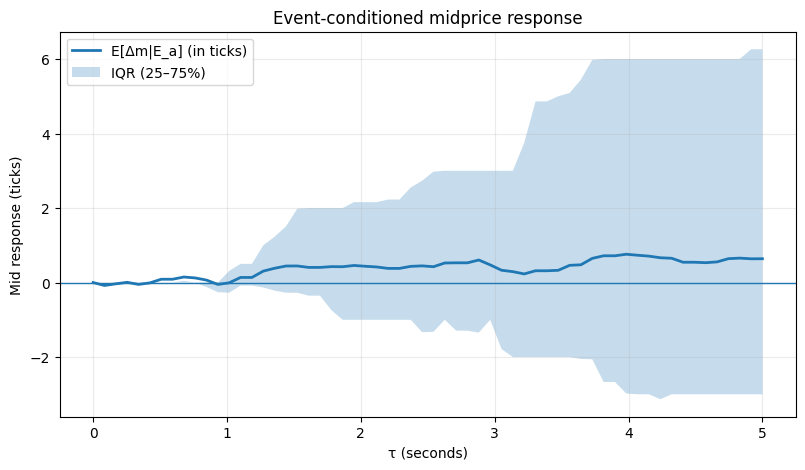

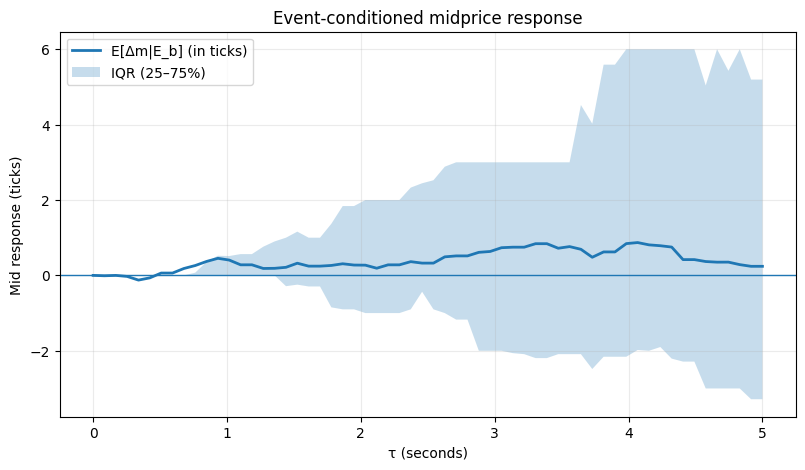

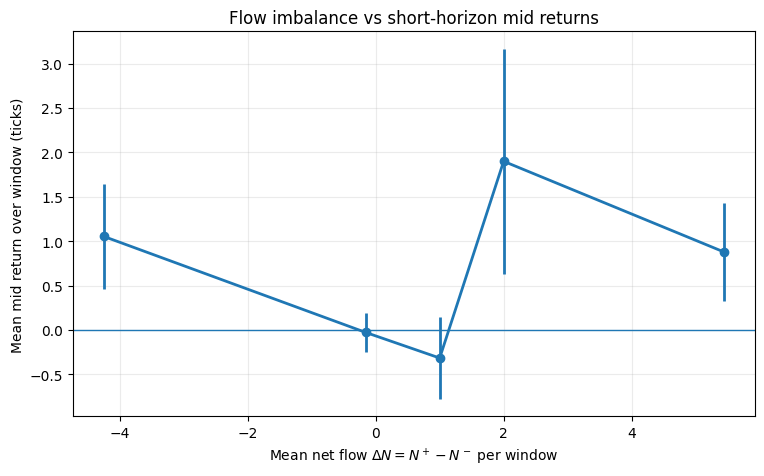

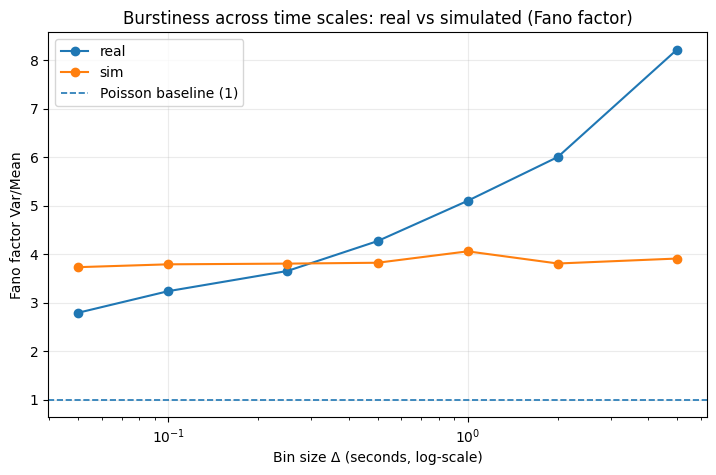

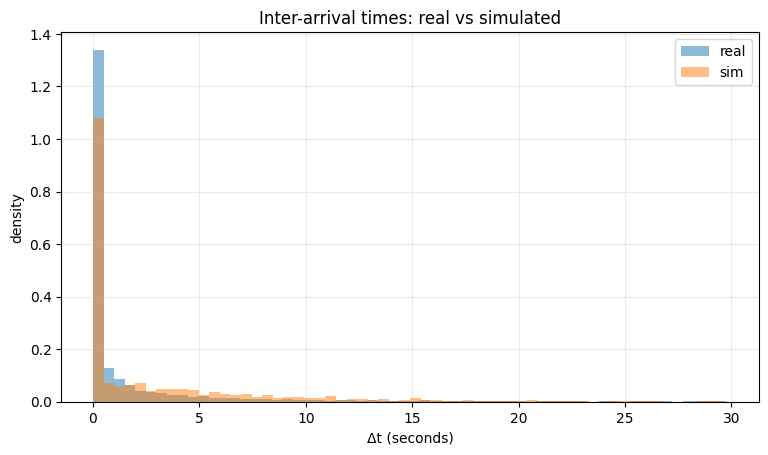

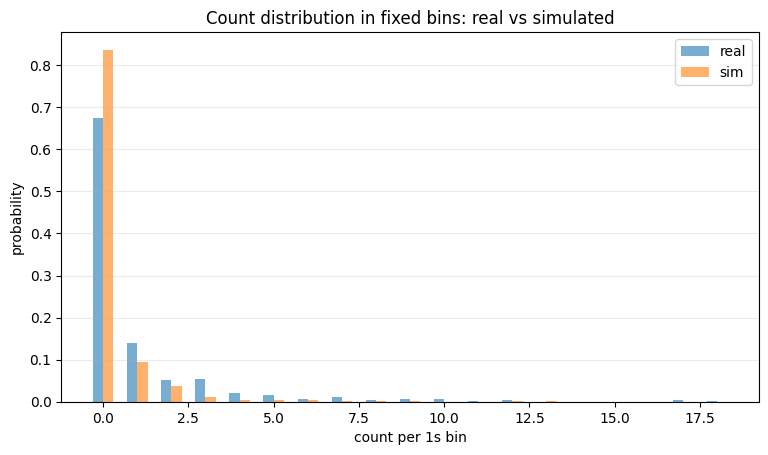

In [ ]:
from thesis_figures import ThesisFigureFactory
figs = ThesisFigureFactory(out_dir="figures/" + str(symbol))

T_EP = 600.0

# Clustering justification (use localized events!)
figs.plot_fano_factor_vs_bins(events_rel=events_2d, T=T_EP, components=["E_a","E_b"],
                              save_name="B0_fano_vs_bins")

# Stability across windows (pass win_results dict directly)
figs.plot_hawkes_stability_over_windows(win_results, save_name="B0_stability_over_windows")
figs.plot_rho_histogram(win_results, save_name="B0_rho_hist")

# 2D reduction evidence (needs full events!)
mid_times  = t_grid
mid_prices = mid_real_grid
tick_size  = mid_tick

components_full = ["E_a","E_b"]  # or add HE_a, HE_b if you want
events_full, marks_full, meta_full = prepare_hawkes_events(
    events, components_full, eps="auto"
)

# Now call the lift plot with events_full (NOT events_2d)
figs.plot_event_type_midmove_lift_multi(
    mid_times=mid_times,
    mid_prices=mid_prices,
    events_rel=events_full,
    T=600,
    components=components_full,
    tick_size=tick_size,
    save_name="B0_lift_vs_horizon_full"
)

# Event impulse response
figs.plot_event_impulse_response(mid_times, mid_prices, events_full["E_a"],
                                 T=T_EP, tick_size=tick_size, label="E_a",
                                 save_name="B0_irf_Ea")

figs.plot_event_impulse_response(mid_times, mid_prices, events_full["E_b"],
                                 T=T_EP, tick_size=tick_size, label="E_b",
                                 save_name="B0_irf_Eb")

# Flow imbalance vs returns (aggressive flow -> returns)
figs.plot_flow_imbalance_vs_returns(
    mid_times, mid_prices,
    buy_mo_times=events_full["E_a"], sell_mo_times=events_full["E_b"],
    T=T_EP, tick_size=tick_size, delta=1.0,
    save_name="B0_flow_imbalance"
)

# Real vs sim (only if you simulated)
sim_events = streams
figs.plot_fano_real_vs_sim(events_full["E_a"], sim_events["E_a"], T=T_EP, save_name="B0_fano_real_sim_Ea")
figs.plot_interarrival_real_vs_sim(events_full["E_a"], sim_events["E_a"], save_name="B0_dt_real_sim_Ea")
figs.plot_count_distribution_real_vs_sim(events_full["E_a"], sim_events["E_a"], T=T_EP, save_name="B0_counts_real_sim_Ea")


# Rolling-window full-day LOB forecasting

This section follows the same dataset construction used in the energy-price forecasting project:

- each observation is a **rolling historical window**;
- the windows move chronologically through the original trading day;
- the model predicts several future horizons directly;
- the final HJB/backtest interval is never used for training.

Here, each input contains the previous **7 minutes** of original LOB states. The shared 1D CNN produces direct **down / no-move / up** probabilities and an uncertainty radius for the 1s, 5s and 10s horizons.


In [ ]:
import importlib
import rolling_lob_forecaster as rlf

# Reload explicitly so Jupyter cannot keep an older local module in memory.
importlib.reload(rlf)

EXPECTED_ROLLING_API = "2026.07.04-rolling-lob-cnn-v1"
assert rlf.ROLLING_SEQUENCE_API_VERSION == EXPECTED_ROLLING_API, (
    f"Wrong rolling_lob_forecaster.py loaded: {rlf.__file__}\n"
    f"Expected API {EXPECTED_ROLLING_API}, got "
    f"{getattr(rlf, 'ROLLING_SEQUENCE_API_VERSION', 'missing')}"
)

from rolling_lob_forecaster import (
    RollingLOBSequenceConfig,
    resample_lob_orderbook_clock_time,
    infer_backtest_application_window,
    fit_rolling_lob_sequence_forecaster,
    plot_rolling_sequence_predictions,
    plot_rolling_sequence_forecast_fan,
    plot_rolling_sequence_training_history,
)

print("Loaded:", rlf.__file__)
print("Rolling-sequence API:", rlf.ROLLING_SEQUENCE_API_VERSION)


## 1. Forecast configuration

The original LOB and all target horizons remain on the **0.1-second clock grid**.

A full seven-minute input would contain 4,201 points at 0.1s resolution. To keep the sequence model tractable, the CNN reads the seven-minute history every **0.5 seconds**, giving 841 ordered timesteps per sample. This does not change the 1s, 5s and 10s targets.

Training origins are one second apart. Predictions inside the held-out backtest window are produced every 0.1 seconds.


In [ ]:
SAMPLE_DT_SECONDS = 0.1
ROLLING_WINDOW_MINUTES = 7.0
SEQUENCE_SAMPLE_SECONDS = 0.5

TRAINING_ORIGIN_STRIDE_SECONDS = 1.0
APPLICATION_ORIGIN_STRIDE_SECONDS = 0.1
HORIZONS_SECONDS = (1.0, 5.0, 10.0)

rolling_cfg = RollingLOBSequenceConfig(
    sample_dt_seconds=SAMPLE_DT_SECONDS,
    rolling_window_minutes=ROLLING_WINDOW_MINUTES,
    sequence_sample_seconds=SEQUENCE_SAMPLE_SECONDS,
    training_origin_stride_seconds=TRAINING_ORIGIN_STRIDE_SECONDS,
    application_origin_stride_seconds=APPLICATION_ORIGIN_STRIDE_SECONDS,
    horizons_seconds=HORIZONS_SECONDS,

    # Chronological pre-backtest splits.
    validation_fraction=0.15,
    calibration_fraction=0.15,

    # Classification and uncertainty.
    deadzone_ticks=0.5,
    radius_quantile=0.90,
    conformal_alpha=0.10,
    move_weight_for_alpha=5.0,
    class_weight_power=0.5,

    # CNN training. Reduce max_epochs during experimentation if needed.
    hidden_channels=(16, 32, 64),
    dropout=0.10,
    max_epochs=10,
    batch_size=256,
    learning_rate=1e-3,
    weight_decay=1e-5,
    patience=4,
    radius_loss_weight=0.5,

    random_state=42,
    device="auto",
    num_workers=0,  # safest setting for Windows/Jupyter
)

print("Rolling history:", rolling_cfg.rolling_window_minutes, "minutes")
print(
    "CNN sequence length:",
    int(round(rolling_cfg.rolling_window_seconds / rolling_cfg.sequence_sample_seconds)) + 1,
)
print("Direct horizons:", rolling_cfg.horizons_seconds)


## 2. Resample the original trading day and identify the held-out application window

The model is trained on the original LOB day, not on `res`. The HJB result is used only to identify the interval where forecasts will be evaluated and visualised.


In [ ]:
lob_clock = resample_lob_orderbook_clock_time(
    data,
    dt_seconds=SAMPLE_DT_SECONDS,
)

application_start_time, application_end_time, used_time_offset = (
    infer_backtest_application_window(
        res_clock=res,
        lob_clock_df=lob_clock,
        proposed_time_offset=float(t_start),
    )
)

print("Original LOB clock rows:", len(lob_clock))
print(
    "Original LOB range:",
    (float(lob_clock["time"].min()), float(lob_clock["time"].max())),
)
print(
    "Held-out HJB/backtest application window:",
    (application_start_time, application_end_time),
)
print("Backtest time offset used:", used_time_offset)

lob_clock.head()


## 3. Build rolling samples and fit the multi-horizon CNN

For every valid forecast origin \(t\), the input is the seven-minute sequence from \(t-7\text{ min}\) to \(t\).

The split is strictly chronological:

1. training windows;
2. validation windows for early stopping;
3. calibration windows for shrinkage and conformal coverage;
4. the final HJB/backtest window for application.

All pre-application targets must finish before the application window starts, so the split is purged against horizon leakage.


In [ ]:
sequence_output = fit_rolling_lob_sequence_forecaster(
    lob_clock_df=lob_clock,
    application_start_time=application_start_time,
    application_end_time=application_end_time,
    config=rolling_cfg,
    price_tick=float(mid_tick),
    verbose=True,
)

rolling_results_by_horizon = sequence_output["results_by_horizon"]
rolling_metrics_table = sequence_output["metrics_table"]
rolling_split_summary = sequence_output["split_summary"]

print("Device:", sequence_output["device"])
print("Price tick:", sequence_output["price_tick"])
print("Input features:", len(sequence_output["feature_columns"]))
print("Timesteps per rolling sample:", sequence_output["sequence_length"])


## 4. Chronological dataset splits


In [ ]:
display(rolling_split_summary)


## 5. Out-of-sample metrics on the HJB/backtest interval


In [ ]:
display(
    rolling_metrics_table[
        [
            "horizon_seconds",
            "n_application_samples",
            "alpha_shrinkage",
            "naive_center_mae",
            "center_mae",
            "center_improvement_vs_naive",
            "classification_accuracy",
            "balanced_accuracy",
            "macro_f1",
            "move_only_direction_accuracy",
            "empirical_coverage",
            "avg_interval_width",
            "winkler_score",
        ]
    ]
)


## 6. Training history


In [ ]:
fig, ax = plot_rolling_sequence_training_history(sequence_output)
plt.show()


## 7. Predicted mid-price against realised mid-price


In [ ]:
for h_seconds, result in rolling_results_by_horizon.items():
    fig, ax = plot_rolling_sequence_predictions(
        result,
        max_points=1200,
        title=f"{symbol}: rolling 7-minute LOB forecast, {h_seconds:g}s ahead",
    )
    plt.show()


## 8. Latest 1s / 5s / 10s forecast fan


In [ ]:
fig, ax = plot_rolling_sequence_forecast_fan(
    sequence_output,
    history_seconds=60.0,
    symbol=symbol,
)
plt.show()


## 9. Probability and center diagnostics


In [ ]:
for h_seconds, result in rolling_results_by_horizon.items():
    pf = result["pred_frame"]
    print(f"\nHorizon: {h_seconds:g}s")
    print("alpha shrinkage:", result["metrics"]["alpha_shrinkage"])
    print(
        "center improvement vs persistence:",
        result["metrics"]["center_improvement_vs_naive"],
    )
    display(
        pf[
            [
                "p_down",
                "p_no_move",
                "p_up",
                "directional_edge",
                "raw_center_delta",
                "center_delta",
                "pred_radius",
            ]
        ].describe()
    )


## 10. Save forecasts and metrics


In [ ]:
rolling_metrics_table.to_csv("rolling_lob_metrics.csv", index=False)
rolling_split_summary.to_csv("rolling_lob_split_summary.csv", index=False)

for h_seconds, result in rolling_results_by_horizon.items():
    result["pred_frame"].to_csv(
        f"rolling_lob_predictions_{h_seconds:g}s.csv",
        index=False,
    )

print("Saved rolling-window metrics, split summary and horizon predictions.")
